In [25]:
import numpy as np
import tensorflow as tf
import torch
import matplotlib.pyplot as plt
from matplotlib import rc
%matplotlib inline 

rc("font", family="Malgun Gothic") #폰트를 교체하는 명령어
plt.rcParams['axes.unicode_minus'] = False #마이너스 기호 깨짐 방지

x=tf.constant(2,3)
x=tf.fill((2,4),value=7)
x.numpy()
x=torch.tensor([1,2,3,4,5])
y=x.numpy()
print(type(x))
print(type(y))

a=tf.random.normal((2,4), mean=0, stddev=1)
a=tf.random.truncated_normal((2,4), mean=0, stddev=1)
a=tf.random.uniform((2,4), minval=-10, maxval=10)
a.numpy()

c=tf.ones((2,2))
d=tf.ones((2,2))
e=c+d
e.numpy()
f=2*e
f.numpy()

c=tf.fill((2,2), value=2.)
d=tf.fill((2,2), 7.)
e=c*d #텐서의 곱은 행렬의 곱이 아니라 같은 위치의 원소끼리 곱임
e.numpy()

a=tf.eye(4)
a.numpy()
a=np.zeros((2,2))
print(a)

<class 'torch.Tensor'>
<class 'numpy.ndarray'>
[[0. 0.]
 [0. 0.]]


In [26]:
r=tf.range(1,6,1)
a=tf.linalg.diag(r) #linalg는 linear algebra를 의미함
a.numpy()
b=tf.linalg.diag_part(a) #행렬의 대각성분만 추출하는 함수
b.numpy()
r

<tf.Tensor: shape=(5,), dtype=int32, numpy=array([1, 2, 3, 4, 5], dtype=int32)>

In [27]:
a=tf.ones((2,3))
a.numpy()
at=tf.linalg.matrix_transpose(a)
at.numpy()

array([[1., 1.],
       [1., 1.],
       [1., 1.]], dtype=float32)

In [28]:
a=tf.ones((2,3))
b=tf.ones((3,4))
c=tf.linalg.matmul(a,b)
c.numpy()

array([[3., 3., 3., 3.],
       [3., 3., 3., 3.]], dtype=float32)

In [29]:
a=tf.ones((2,2), dtype=tf.int32)
a.numpy()
b=tf.cast(a, dtype=tf.float32)
b.numpy()

array([[1., 1.],
       [1., 1.]], dtype=float32)

In [30]:
a=tf.ones((8))
a.numpy()
b=tf.reshape(a, (2,4))
b.numpy()
c=tf.reshape(b, (2,2,2))
c.numpy()

array([[[1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.]]], dtype=float32)

In [31]:
a=tf.ones(3)
a.get_shape()
a.numpy()
b=tf.expand_dims(a,0)
b.get_shape() #TensorShape([1, 3]): 1행3열의 2차원 텐서->1은 batch, 3은 feature(데이터의 크기)
b.numpy()
c=tf.squeeze(b)
c.get_shape()

TensorShape([3])

In [32]:
a=tf.ones((2,2)) #dtype=tf.float32임
b=tf.range(0,2,1,dtype=tf.float32) #0~1까지 1증가-> 0, 1
b
c=a+b #벡터 b[0,1]를 행렬 a의 모든 행[1,1]에 더함->Broadcasting이라고 함
c

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[1., 2.],
       [1., 2.]], dtype=float32)>

In [33]:
print(tf.__version__)
a=tf.Variable(tf.ones((2,2)))
a.numpy()
a

2.20.0


<tf.Variable 'Variable:0' shape=(2, 2) dtype=float32, numpy=
array([[1., 1.],
       [1., 1.]], dtype=float32)>

In [34]:
v=tf.Variable([0,0,0,0,0])
v.scatter_nd_update([[0],[3]], [1,3]) #첫번째 값은 인덱스 리스트이며, 인덱스는 차원에 맞춰 지정해야 함
v.numpy()

array([1, 0, 0, 3, 0], dtype=int32)

In [35]:
v=tf.Variable(10.0, name="temp") #초기값 10.0
v.assign(20.0) #값을 덮어씀(같은 메모리 위치에서 값만 바꿈)
v.assign_add(5.) #5.를 더함
v.assign_sub(3.) #3.을 뺌
#v.assign(tf.ones(2,2)) 텐서는 처음 만들어질 때 shape가 정해짐. shape에 맞게 값을 저장해야 함
v.numpy()
print(v.name)
print(v.dtype)
print(v.shape)
print(v.trainable) #아주 중요! 이 변수가 학습(미분) 대상인지 아닌지를 True/False로 알려줌

temp:0
<dtype: 'float32'>
()
True


In [36]:
b=np.zeros((2,3))
a=np.eye(3)
b=np.zeros((10,))
b=np.array((-1,-1))
c=.1*np.eye(2)
c

array([[0.1, 0. ],
       [0. , 0.1]])

Text(0, 0.5, 'y')

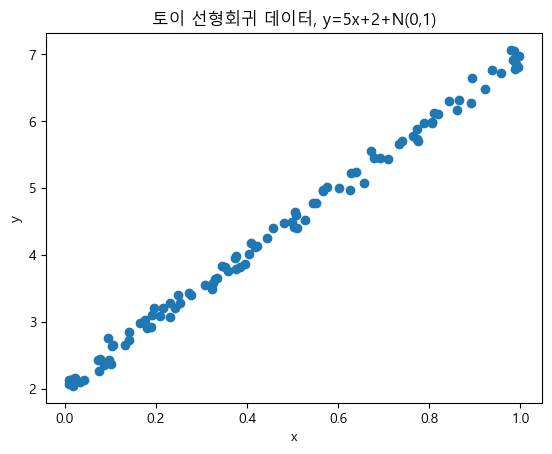

In [37]:
N=100
w_true=5
b_true=2
noise_scale=.1 #noise stddev
x_np=np.random.rand(N,1) #Nx1행렬, 0~1사이값
noise=np.random.normal(scale=noise_scale, size=(N,1))
y_np=np.reshape(w_true*x_np+b_true+noise, (-1))  #y_np=w_true*x_np+b_true+noise와 동일함
plt.scatter(x_np, y_np)
plt.title("토이 선형회귀 데이터, y=5x+2+N(0,1)")
plt.xlabel("x")
plt.ylabel("y")

x_np shape: (100, 2)
y_np shape: (100,)


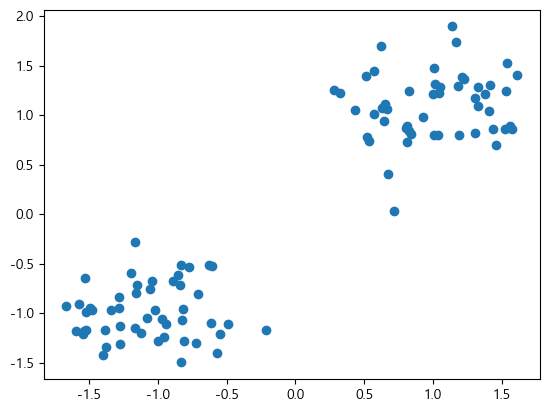

In [38]:
N=100
y_zeros=np.zeros(np.asarray(N/2, dtype=np.int32))
y_ones=np.ones(np.asarray(N/2, dtype=np.int32))
y_np=np.concatenate([y_zeros, y_ones]) #np.shape(y_np) : (100,)
x_zeros=np.random.multivariate_normal(mean=np.array([-1,-1]), cov=.1*np.eye(2), size=(np.asarray(N/2,dtype=np.int32),))
x_ones=np.random.multivariate_normal(mean=np.array([1,1]), cov=.1*np.eye(2), size=(np.asarray(N/2,dtype=np.int32),))
x_np=np.vstack([x_zeros,x_ones])
print("x_np shape:", np.shape(x_np))
print("y_np shape:", np.shape(y_np))
plt.scatter(x_np[:,0], x_np[:,1])

In [39]:
w=tf.Variable((3,))
l=tf.reduce_sum(w)
gradW=tf.GradientTape(l,w)
print(gradW)

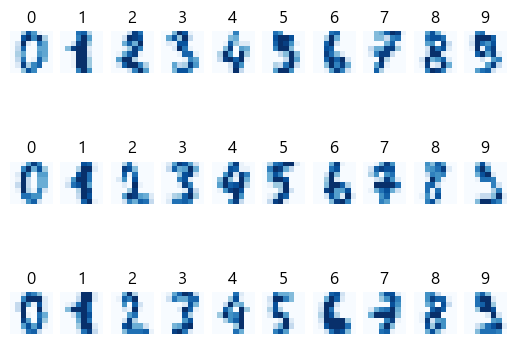

Score= 0.9711111111111111


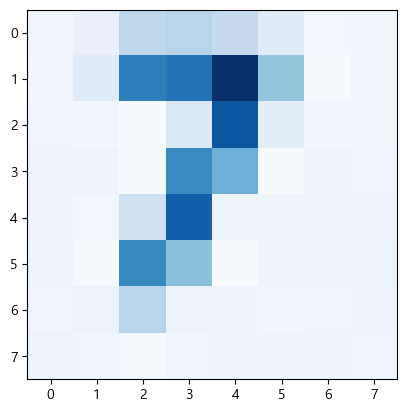

[ 0.75    1.1875  3.75    4.0625  3.5     1.8125  0.625   0.75    0.6875
  1.8125  9.3125  9.8125 13.1875  5.375   0.3125  0.75    0.8125  0.75
  0.25    2.125  11.3125  1.5625  0.6875  0.75    0.875   0.875   0.25
  8.6875  6.625   0.3125  0.875   0.8125  0.875   0.5625  2.9375 10.8125
  1.      0.875   0.875   0.875   0.9375  0.4375  8.75    5.6875  0.25
  0.875   0.875   0.9375  0.8125  1.0625  4.0625  0.9375  0.875   0.75
  0.8125  0.875   0.9375  0.8125  0.5     0.8125  0.875   0.875   0.875
  0.8125]
예측 숫자는 :  [7]


In [40]:
#숫자인식기(scikit-learn, keras사용): 숫자 이미지를 데이터 배열로 변환, 학습, 인식테스트/인식률 계산
import matplotlib.pyplot as plt
import sklearn.datasets
import sklearn.svm
from PIL import Image #PIL(Python Imaging Library), pillow모듈의 원천
import numpy as np
from sklearn.model_selection import train_test_split

digits=sklearn.datasets.load_digits()
for i in range(30):
    plt.subplot(3,10,i+1)
    plt.axis('off')
    plt.title(digits.target[i])
    plt.imshow(digits.images[i], cmap="Blues") #cmap: "gray","Greys","binary","bone","pink","copper","viridis","plasma","inferno","magma","cividis","RdBu","coolwarm","bwr","Reds","Greens","Blues","Oranges"
plt.show()
x_train, x_test, y_train, y_test=train_test_split(digits.data, digits.target, test_size=0.25, random_state=0)

def conv_image_to_data(filename):
    gsimage=Image.open(filename).convert('L') #grayscale로 변환
    gsimage=gsimage.resize((8,8))
    gsimage=np.subtract(255, gsimage)
    digitImage=16*np.divide(gsimage, 256)
    digitImage=digitImage.flatten()
    plt.imshow(gsimage, cmap='Blues')
    plt.show()
    print(digitImage)
    return digitImage

learning_model=sklearn.svm.SVC(gamma=0.0001) # 서포트 벡터 분류기(Support Vector Classifier)를 생성
learning_model.fit(x_train, y_train)
score=learning_model.score(x_test, y_test)
print("Score=", score)
data=conv_image_to_data("7.png")
n=learning_model.predict([data])
print("예측 숫자는 : ", n)

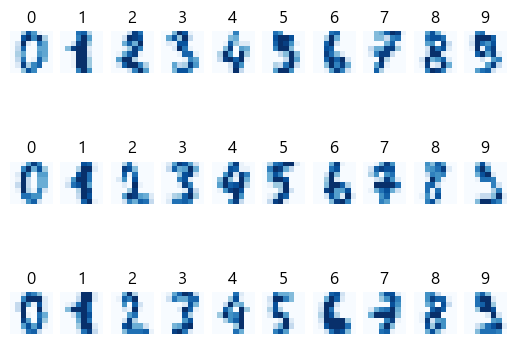

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,938 (27.10 KB)

 Trainable params: 6,938 (27.10 KB)

 Non-trainable params: 0 (0.00 B)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Training start...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9178 - loss: 0.3016  
Test loss: 0.3016
Test accuracy: 0.9178


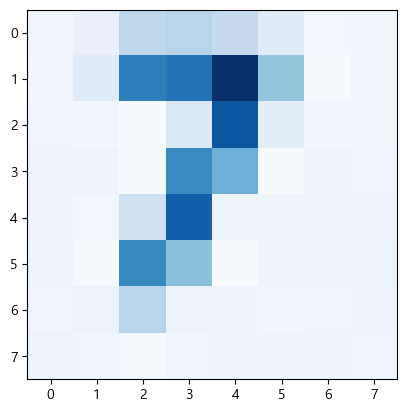

[ 0.75    1.1875  3.75    4.0625  3.5     1.8125  0.625   0.75    0.6875
  1.8125  9.3125  9.8125 13.1875  5.375   0.3125  0.75    0.8125  0.75
  0.25    2.125  11.3125  1.5625  0.6875  0.75    0.875   0.875   0.25
  8.6875  6.625   0.3125  0.875   0.8125  0.875   0.5625  2.9375 10.8125
  1.      0.875   0.875   0.875   0.9375  0.4375  8.75    5.6875  0.25
  0.875   0.875   0.9375  0.8125  1.0625  4.0625  0.9375  0.875   0.75
  0.8125  0.875   0.9375  0.8125  0.5     0.8125  0.875   0.875   0.875
  0.8125]
Data shape=(64,)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
[[0.02913943 0.00485677 0.47677353 0.02692943 0.00564714 0.00182408
  0.00051088 0.40211865 0.036913   0.01528706]]
예측 숫자는 2
확신도: 0.4768


In [43]:
#숫자인식기(scikit-learn, keras사용): 숫자 이미지를 데이터 배열로 변환, 학습, 인식테스트/인식률 계산
import matplotlib.pyplot as plt
import sklearn.datasets
from PIL import Image #PIL(Python Imaging Library), pillow모듈의 원천
import numpy as np
import tensorflow as tf
import graphviz, pydot
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
import sys

#print(sys.executable) #python 실행 경로 출력

digits=sklearn.datasets.load_digits()
for i in range(30):
    plt.subplot(3,10,i+1)
    plt.axis('off')
    plt.title(digits.target[i])
    plt.imshow(digits.images[i], cmap="Blues") #cmap: "gray","Greys","binary","bone","pink","copper","viridis","plasma","inferno","magma","cividis","RdBu","coolwarm","bwr","Reds","Greens","Blues","Oranges"
plt.show()
x_train, x_test, y_train, y_test=train_test_split(digits.data, digits.target, test_size=0.25, random_state=0, shuffle=True)

def conv_image_to_data(filename):
    gsimage=Image.open(filename).convert('L') #grayscale로 변환
    gsimage=gsimage.resize((8,8))
    gsimage=np.subtract(255, gsimage)
    digitImage=16*np.divide(gsimage, 256)
    digitImage=digitImage.flatten()
    plt.imshow(gsimage, cmap='Blues')
    plt.show()
    print(digitImage)
    return digitImage

inputs=Input(shape=(64,))
x=Dense(64, activation='relu')(inputs)
x=Dense(32, activation='relu')(x)
x=Dense(16, activation='relu')(x)
outputs=Dense(10, activation='softmax')(x)

model=Model(inputs=[inputs], outputs=[outputs])
model.summary()
plot_model(model) #, show_shapes=True, show_layer_names=True)

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])  #accuracy는 전체 개수에서 맞춘 개수를 나타냄
print("Training start...")
model.fit(x_train, y_train, epochs=10, batch_size=64, verbose=0)
test_loss, test_accuracy=model.evaluate(x_test, y_test)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
data=conv_image_to_data("7.png")
print(f"Data shape={data.shape}")
n=model.predict([data.reshape(1,64)]) #입력은 2차원으로 입력해야 함
print(n)
pred_digit=np.argmax(n)
print(f"예측 숫자는 {pred_digit}")
print(f"확신도: {n[0,pred_digit]:.4f}")